In [36]:
# =============================================================================
# CELL 1: Audit configuration + handoff load
# =============================================================================

import json
import warnings
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# --- Handoff contract --------------------------------------------------------
HANDOFF_PATH = Path('cluster_data/handoff_to_03.json')
if not HANDOFF_PATH.exists():
    raise FileNotFoundError(
        f"❌ {HANDOFF_PATH} not found. "
        f"Notebook 02 must complete before 03."
    )
with open(HANDOFF_PATH) as _f:
    HANDOFF = json.load(_f)

if HANDOFF.get('mode') != 'peer_group_benchmarking_audit':
    raise RuntimeError(
        f"❌ Handoff mode is {HANDOFF.get('mode')!r}, expected "
        f"'peer_group_benchmarking_audit'. Re-run notebook 02."
    )

# --- Handoff schema version --------------------------------------------------
# v1: original handoff (no R² test). Backwards-compatible read.
# v2: adds attribution_r2_test and attribution_r2_gap (Priority #2 fix).
_HANDOFF_SCHEMA = int(HANDOFF.get('schema_version', 1))

# --- Inputs ------------------------------------------------------------------
_IN = HANDOFF['inputs']

TRIAL_ID_COL             = _IN['trial_id_col']
REFERENCE_CORPUS_PATH    = Path(_IN['reference_corpus_path'])
CANONICAL_SPLIT_PATH     = Path(_IN['canonical_split_path'])
PEER_ASSIGNMENTS_PATH    = Path(_IN['peer_assignments_path'])
PEER_DISTRIBUTIONS_PATH  = Path(_IN['peer_distributions_path'])
PEER_PROFILES_PATH       = Path(_IN['peer_feature_profiles_path'])
PEER_RISK_FACTORS_PATH   = Path(_IN['peer_risk_factors_path'])
AUDIT_FEATURE_POOL_PATH  = Path(_IN['audit_feature_pool_path'])
TEXT_INVENTORY_PATH      = Path(_IN['text_inventory_path'])
TEMPORAL_REFERENCE_PATH  = Path(_IN['temporal_reference_path'])
ELIGIBILITY_TEXT_PATH    = Path(_IN['eligibility_text_path'])

AUDIT_FEATURE_POOL       = list(_IN['audit_feature_pool'])
TEXT_INVENTORY           = _IN['text_feature_inventory']
TEMPORAL_REFERENCE       = _IN['temporal_reference']

# --- Reference metrics -------------------------------------------------------
REFERENCE_METRICS = HANDOFF['reference_metrics']

# --- Output ------------------------------------------------------------------
OUTPUT_DIR = Path('audit_output')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Business thresholds (from notebook 02, kept identical) ------------------
BUSINESS_LABELS = ['Small (<1yr)', 'Medium (1-3yr)', 'Large (>3yr)']
BUSINESS_BINS   = [-np.inf, 365, 1095, np.inf]

# --- Verdict thresholds ------------------------------------------------------
# Percentile bands for classifying a finished trial against its peers.
# Below p05 or above p95 -> flagged as outlier.
# Between p25-p75             -> typical.
# Between p75-p95             -> slow.
# Between p05-p25             -> fast.
OUTLIER_LOW_PCT  = 5.0
OUTLIER_HIGH_PCT = 95.0
TYPICAL_LOW_PCT  = 25.0
TYPICAL_HIGH_PCT = 75.0

# Minimum peer-group size below which we fall back to a coarser grouping.
MIN_PEERS_FOR_AUDIT = 30

# ---- Startup banner ---------------------------------------------------------
print("=" * 78)
print("03 → handoff_to_03.json LOADED")
print("=" * 78)
print(f"  Mode:                    {HANDOFF['mode']}")
print(f"  Handoff schema:          v{_HANDOFF_SCHEMA}")
print(f"  Trial ID column:         {TRIAL_ID_COL}")
print(f"  Reference corpus:        {REFERENCE_CORPUS_PATH}")
print(f"  Peer assignments:        {PEER_ASSIGNMENTS_PATH}")
print(f"  Peer distributions:      {PEER_DISTRIBUTIONS_PATH}")
print(f"  Peer risk factors:       {PEER_RISK_FACTORS_PATH}")
print(f"  Audit feature pool:      {len(AUDIT_FEATURE_POOL)} features")
print(f"  Reference trials:        {REFERENCE_METRICS['n_trials']:,}")
print(f"  Peer groups:             {REFERENCE_METRICS['n_peer_groups']}")
print(f"  Reliable peer groups:    {REFERENCE_METRICS['n_peer_groups_reliable']}")
print(f"  Attribution model:       {REFERENCE_METRICS['attribution_model']}")
print(f"  Attribution R² (train):  {REFERENCE_METRICS['attribution_r2_train']:.4f}")

# --- Attribution R²(test) + gap display --------------------------------------
# FIX (Priority #2): surface the train-test R² gap so a reader of this
# notebook knows whether the SHAP attributions they are about to consume
# are trustworthy. Missing fields are tolerated for v1 handoffs.
_r2_test = REFERENCE_METRICS.get('attribution_r2_test')
_r2_gap  = REFERENCE_METRICS.get('attribution_r2_gap')

if _r2_test is not None and _r2_gap is not None:
    print(f"  Attribution R² (test):   {_r2_test:.4f}")
    print(f"  Attribution R² gap:      {_r2_gap:+.4f}")
    if _r2_gap > 0.10:
        print(f"  ⚠️  Train-test R² gap exceeds 0.10 — the attribution "
              f"model is overfitting.")
        print(f"      SHAP attributions in the audit should be read as "
              f"directional, not precise.")
    elif _r2_gap < -0.02:
        print(f"  ℹ️  Test R² exceeds train R² — no evidence of "
              f"overfitting.")
    else:
        print(f"  ✅ Train-test R² gap is within tolerance (< 0.10).")
else:
    print(f"  Attribution R² (test):   (not in handoff — v1 schema)")
    print(f"  ℹ️  Re-run notebook 02 with the Priority #2 fix to "
          f"populate R²(test).")

print(f"  Output directory:        {OUTPUT_DIR}")
print("=" * 78)

03 → handoff_to_03.json LOADED
  Mode:                    peer_group_benchmarking_audit
  Handoff schema:          v2
  Trial ID column:         protocolSection.identificationModule.nctId
  Reference corpus:        cluster_data\shared\trial_reference_corpus.parquet
  Peer assignments:        cluster_data\shared\peer_group_assignments.parquet
  Peer distributions:      cluster_data\shared\peer_distributions.parquet
  Peer risk factors:       cluster_data\shared\peer_risk_factors.json
  Audit feature pool:      107 features
  Reference trials:        171,881
  Peer groups:             44
  Reliable peer groups:    39
  Attribution model:       XGBRegressor
  Attribution R² (train):  0.4134
  Attribution R² (test):   0.3819
  Attribution R² gap:      +0.0316
  ✅ Train-test R² gap is within tolerance (< 0.10).
  Output directory:        audit_output


In [37]:
# =============================================================================
# CELL 2: Load all peer-group artifacts
# =============================================================================

print("\n" + "=" * 78)
print("LOADING PEER-GROUP ARTIFACTS")
print("=" * 78)

# --- 1. Reference corpus -----------------------------------------------------
print(f"\nReading reference corpus:\n  {REFERENCE_CORPUS_PATH}")
corpus = pd.read_parquet(REFERENCE_CORPUS_PATH)
print(f"  ✅ {len(corpus):,} trials × {corpus.shape[1]} columns")

# --- 2. Peer assignments -----------------------------------------------------
print(f"\nReading peer assignments:\n  {PEER_ASSIGNMENTS_PATH}")
peer_assignments = pd.read_parquet(PEER_ASSIGNMENTS_PATH)
peer_assignments['trial_id'] = peer_assignments['trial_id'].astype(str)
print(f"  ✅ {len(peer_assignments):,} rows, "
      f"{peer_assignments['peer_group'].nunique()} peer groups")

# --- 3. Peer distributions ---------------------------------------------------
print(f"\nReading peer distributions:\n  {PEER_DISTRIBUTIONS_PATH}")
peer_dist = pd.read_parquet(PEER_DISTRIBUTIONS_PATH)
peer_dist = peer_dist.set_index('regime_bucket')
print(f"  ✅ {len(peer_dist)} peer groups")
print(f"     Reliable (n>={MIN_PEERS_FOR_AUDIT}): "
      f"{int(peer_dist['reliable'].sum())}")
print(f"     Unreliable:              "
      f"{int((~peer_dist['reliable']).sum())}")

# --- 4. Peer feature profiles ------------------------------------------------
print(f"\nReading peer feature profiles:\n  {PEER_PROFILES_PATH}")
with open(PEER_PROFILES_PATH) as f:
    peer_profiles = json.load(f)
print(f"  ✅ {len(peer_profiles)} profiles")

# --- 5. Peer risk factors (SHAP) ---------------------------------------------
print(f"\nReading peer risk factors:\n  {PEER_RISK_FACTORS_PATH}")
with open(PEER_RISK_FACTORS_PATH) as f:
    peer_risk = json.load(f)
print(f"  ✅ {peer_risk['n_peer_groups_scored']} peer groups with attributions")
print(f"     Model: {peer_risk['model_family']}, "
      f"R²(train)={peer_risk['model_r2_train']:.4f}")

# --- 6. Canonical split (for stability diagnostics only) ---------------------
print(f"\nReading canonical split:\n  {CANONICAL_SPLIT_PATH}")
canonical_split = pd.read_parquet(CANONICAL_SPLIT_PATH)
canonical_split['trial_id'] = canonical_split['trial_id'].astype(str)
print(f"  ✅ {len(canonical_split):,} rows, "
      f"{canonical_split['split'].value_counts().to_dict()}")

# --- 7. Sanity: trial universes match ----------------------------------------
_corpus_ids = set(corpus[TRIAL_ID_COL].astype(str))
_assign_ids = set(peer_assignments['trial_id'])
if _corpus_ids != _assign_ids:
    raise RuntimeError(
        f"❌ Corpus/assignments trial mismatch: "
        f"corpus={len(_corpus_ids):,}, assignments={len(_assign_ids):,}"
    )
print(f"\n  ✅ Corpus and peer assignments cover the same "
      f"{len(_corpus_ids):,} trials.")

# --- 8. Sanity: peer groups align --------------------------------------------
_pd_groups = set(peer_dist.index)
_as_groups = set(peer_assignments['peer_group'])
if _as_groups != _pd_groups:
    raise RuntimeError(
        f"❌ Peer groups in assignments ({len(_as_groups)}) "
        f"differ from distributions ({len(_pd_groups)})"
    )
print(f"  ✅ All {len(_pd_groups)} peer groups have a distribution.")

print("\n" + "=" * 78)
print("LOAD COMPLETE")
print("=" * 78)


LOADING PEER-GROUP ARTIFACTS

Reading reference corpus:
  cluster_data\shared\trial_reference_corpus.parquet
  ✅ 171,881 trials × 141 columns

Reading peer assignments:
  cluster_data\shared\peer_group_assignments.parquet
  ✅ 171,881 rows, 44 peer groups

Reading peer distributions:
  cluster_data\shared\peer_distributions.parquet
  ✅ 44 peer groups
     Reliable (n>=30): 39
     Unreliable:              5

Reading peer feature profiles:
  cluster_data\shared\peer_feature_profiles.json
  ✅ 44 profiles

Reading peer risk factors:
  cluster_data\shared\peer_risk_factors.json
  ✅ 39 peer groups with attributions
     Model: XGBRegressor, R²(train)=0.4134

Reading canonical split:
  cluster_data\shared\canonical_split.parquet
  ✅ 171,881 rows, {'train': 137454, 'test': 34427}

  ✅ Corpus and peer assignments cover the same 171,881 trials.
  ✅ All 44 peer groups have a distribution.

LOAD COMPLETE


In [38]:
# =============================================================================
# CELL 3: Peer-assignment helper — build_strategy_A_partition
# =============================================================================
# This function must be BYTE-IDENTICAL to the one in notebook 02's Cell 9.
# It is duplicated here so that 03 can assign an incoming trial's peer group
# without re-loading notebook 02. If you change one, change both.

from clinical_trial_benchmarking.taxonomy import (
    OBSERVATIONAL_MODEL_MAP,
    OBSERVATIONAL_PERSPECTIVE_MAP,
)


def _normalize_obs_enum(raw, mapping):
    if raw is None:
        return 'other'
    try:
        if pd.isna(raw):
            return 'other'
    except (ValueError, TypeError):
        return 'other'
    s = str(raw).upper().strip().replace('-', '_').replace(' ', '_')
    return mapping.get(s, 'other')


def _build_stage_bucket(phase_score):
    _ps = phase_score.fillna(0).astype(int)
    return pd.Series(
        np.select(
            [_ps == 0, _ps == 1, _ps == 2, _ps.isin([3, 4])],
            ['unphased', 'exploratory', 'pivotal', 'confirmatory'],
            default='unphased',
        ),
        index=phase_score.index,
    )


def _build_scope_bucket(num_sites, num_countries):
    _s = num_sites.fillna(0).astype(int)
    _c = num_countries.fillna(0).astype(int)

    no_data = (_s == 0) & (_c == 0)
    single  = (_s <= 1) & (_c <= 1) & ~no_data
    regional = (_s <= 10) & (_c <= 3) & ~no_data & ~single

    return pd.Series(
        np.select(
            [no_data, single, regional],
            ['unknown', 'single-site', 'regional'],
            default='multinational',
        ),
        index=num_sites.index,
    )


def _build_observational_label(df_in):
    _M = 'protocolSection.designModule.designInfo.observationalModel'
    _P = 'protocolSection.designModule.designInfo.timePerspective'
    raw_m = df_in[_M] if _M in df_in.columns else pd.Series(['other'] * len(df_in), index=df_in.index)
    raw_p = df_in[_P] if _P in df_in.columns else pd.Series(['other'] * len(df_in), index=df_in.index)
    m = raw_m.apply(lambda v: _normalize_obs_enum(v, OBSERVATIONAL_MODEL_MAP))
    p = raw_p.apply(lambda v: _normalize_obs_enum(v, OBSERVATIONAL_PERSPECTIVE_MAP))
    return 'obs::' + m.astype(str) + '::' + p.astype(str)


def build_strategy_A_partition(df_in):
    """
    Canonical peer-group label.

    Interventional -> "<stage>::<scope>"
    Observational  -> "obs::<model>::<perspective>"
    """
    is_interv = (df_in['study_type'] == 'INTERVENTIONAL')
    stage = _build_stage_bucket(df_in['phase_score'])
    scope = _build_scope_bucket(df_in['num_sites'], df_in['num_countries'])
    interv_label = stage.astype(str) + '::' + scope.astype(str)
    obs_label = _build_observational_label(df_in)
    return pd.Series(
        np.where(is_interv.values, interv_label.values, obs_label.values),
        index=df_in.index,
    )


print("✅ build_strategy_A_partition ready.")

✅ build_strategy_A_partition ready.


In [39]:
# =============================================================================
# CELL 4: audit_trial() — the core audit function
# =============================================================================
# Given a finished trial's design features and its ACTUAL duration, produce
# a structured audit report:
#
#   1. Assign to a peer group (deterministic).
#   2. Look up that group's duration distribution.
#   3. Compute where the trial's duration sits.
#   4. Attribute the position using per-peer SHAP risk factors.
#   5. Emit a verdict (unusually fast / typical / slow / unusually slow).
#
# This function is retrospective: it requires the trial to be finished, and
# it consumes the ACTUAL duration. It does not predict anything.
#
# FIX (categorization propagation): _attribute_within_peer now copies the
# categorization fields (category, category_label, direction_gloss) from
# the persisted risk-factor record into the returned attribution. Without
# this, the renderer sees category=None and cannot split the report into
# actionable vs. contextual blocks.

def _percentile_rank(values: np.ndarray, x: float) -> float:
    """Fraction of peer values strictly less than x, in percent."""
    if len(values) == 0:
        return float('nan')
    return float((values < x).mean() * 100.0)


def _find_trial_rows(trial_ids):
    """
    Return boolean mask of corpus rows matching the given trial IDs.
    Accepts a single ID or an iterable.
    """
    if isinstance(trial_ids, str):
        trial_ids = [trial_ids]
    ids = set(str(t) for t in trial_ids)
    return corpus[TRIAL_ID_COL].astype(str).isin(ids).values


def _describe_position(pct: float) -> str:
    """Map a percentile to a human-readable verdict."""
    if np.isnan(pct):
        return 'unknown'
    if pct < OUTLIER_LOW_PCT:
        return 'unusually fast'
    if pct < TYPICAL_LOW_PCT:
        return 'fast'
    if pct <= TYPICAL_HIGH_PCT:
        return 'typical'
    if pct <= OUTLIER_HIGH_PCT:
        return 'slow'
    return 'unusually slow'


def _attribute_within_peer(peer_group: str, features: dict, top_k: int = 5):
    """
    Return the trial's top-K SHAP-attributed features, restricted to those
    that appear in the peer group's risk-factor table.

    The features dict is a raw feature name -> value mapping for the trial.
    Only features present in the peer group's SHAP table are reported, so
    attributions are always peer-relevant.

    Each returned record carries:
      feature, value, mean_abs_shap, direction,
      category, category_label, direction_gloss

    The last three are copied verbatim from the persisted risk-factor
    record. They are display aids consumed by render_audit_report().
    Missing values propagate as None; the renderer tolerates them.
    """
    rf = peer_risk['risk_factors'].get(peer_group)
    if not rf:
        return []

    out = []
    for entry in rf[:top_k]:
        feat = entry['feature']
        val = features.get(feat)
        out.append({
            'feature':          feat,
            'value':            val,
            'mean_abs_shap':    float(entry['mean_abs_shap']),
            'direction':        entry['direction'],
            # FIX: propagate categorization fields so the renderer can
            # partition the report into actionable vs. contextual blocks.
            'category':         entry.get('category'),
            'category_label':   entry.get('category_label'),
            'direction_gloss':  entry.get('direction_gloss'),
        })
    return out


def audit_trial(trial_id=None,
                features=None,
                actual_duration_days=None,
                peer_group_override=None):
    """
    Audit a finished trial against its peer group.

    Parameters
    ----------
    trial_id : str, optional
        NCT ID. If provided and present in the reference corpus, the trial's
        features and duration are read from the corpus.
    features : dict, optional
        Design features for a trial NOT in the corpus. Must include
        'study_type', 'phase_score', 'num_sites', 'num_countries', plus any
        other audit features you want attributed.
    actual_duration_days : float, optional
        Required if `features` is provided and `trial_id` is not.
    peer_group_override : str, optional
        Force a specific peer group instead of deriving it. Useful for
        "what if this trial had been pivotal instead of exploratory?"

    Returns
    -------
    dict — the audit report.
    """
    # ------------------------------------------------------------------
    # 1. Resolve the trial's inputs
    # ------------------------------------------------------------------
    if trial_id is not None:
        mask = _find_trial_rows(trial_id)
        if not mask.any():
            raise ValueError(f"❌ Trial {trial_id!r} not found in reference corpus.")
        row = corpus[mask].iloc[0]
        features = row.to_dict()
        actual_duration_days = float(row['duration_days'])
        _source = 'corpus'
    else:
        if features is None or actual_duration_days is None:
            raise ValueError(
                "❌ Provide either trial_id, or both features and "
                "actual_duration_days."
            )
        _source = 'caller'

    # ------------------------------------------------------------------
    # 2. Assign to a peer group
    # ------------------------------------------------------------------
    if peer_group_override is not None:
        peer_group = str(peer_group_override)
    else:
        # Build a one-row frame with the axes the partition needs.
        row_df = pd.DataFrame([{
            'study_type':   features.get('study_type', 'INTERVENTIONAL'),
            'phase_score':  features.get('phase_score', 0),
            'num_sites':    features.get('num_sites', 0),
            'num_countries': features.get('num_countries', 0),
        }])
        peer_group = str(build_strategy_A_partition(row_df).iloc[0])

    # ------------------------------------------------------------------
    # 3. Look up the peer distribution
    # ------------------------------------------------------------------
    if peer_group not in peer_dist.index:
        return {
            'trial_id':       trial_id,
            'peer_group':     peer_group,
            'status':         'unknown_peer_group',
            'message':        f"Peer group {peer_group!r} has no distribution "
                              f"in the reference corpus.",
        }

    peers = peer_dist.loc[peer_group]
    n_peers = int(peers['n_with_duration'])
    reliable = bool(peers['reliable'])

    # ------------------------------------------------------------------
    # 4. Position within the peer distribution
    # ------------------------------------------------------------------
    peer_values = corpus.loc[
        corpus['regime_bucket'] == peer_group, 'duration_days'
    ].dropna().values

    pct = _percentile_rank(peer_values, actual_duration_days)
    verdict = _describe_position(pct)

    peer_median = float(peers['p50_days'])
    peer_p10 = float(peers['p10_days'])
    peer_p90 = float(peers['p90_days'])
    peer_p05 = float(peers['p05_days'])
    peer_p95 = float(peers['p95_days'])

    delta_vs_median_days = actual_duration_days - peer_median
    delta_vs_median_pct = (
        100.0 * delta_vs_median_days / peer_median
        if peer_median > 0 else 0.0
    )

    # ------------------------------------------------------------------
    # 5. Attribute the position
    # ------------------------------------------------------------------
    attributions = _attribute_within_peer(peer_group, features, top_k=5)

    # ------------------------------------------------------------------
    # 6. Build the report
    # ------------------------------------------------------------------
    return {
        'trial_id':             trial_id,
        'source':               _source,
        'peer_group':           peer_group,
        'peer_group_size':      n_peers,
        'peer_group_reliable':  reliable,

        'actual_days':          float(actual_duration_days),
        'actual_years':         float(actual_duration_days / 365.25),

        'peer_median_days':     peer_median,
        'peer_p05_days':        peer_p05,
        'peer_p10_days':        peer_p10,
        'peer_p90_days':        peer_p90,
        'peer_p95_days':        peer_p95,

        'percentile':           pct,
        'verdict':              verdict,
        'delta_vs_median_days': delta_vs_median_days,
        'delta_vs_median_pct':  delta_vs_median_pct,

        'top_attributions':     attributions,

        'generated_at':         datetime.now(timezone.utc).isoformat(),
    }


print("✅ audit_trial() ready (categorization propagated).")

✅ audit_trial() ready (categorization propagated).


In [40]:
# =============================================================================
# CELL 5: Fallback grouping for small peer groups
# =============================================================================
# If a peer group has fewer than MIN_PEERS_FOR_AUDIT trials, the benchmark
# is not statistically meaningful. Fall back to a coarser grouping:
#
#   Interventional: drop scope, keep stage  ->  "<stage>"
#                   drop stage, keep scope  ->  "::<scope>"
#   Observational:  keep model only         ->  "obs::<model>"
#
# The audit always reports which grouping level was used.

def _coarse_peer_group(peer_group: str, level: str) -> str:
    """
    Coarsen a peer group.
      level='stage' -> keep stage only for interventional.
      level='scope' -> keep scope only for interventional.
      level='model' -> keep model only for observational.
    """
    if peer_group.startswith('obs::'):
        parts = peer_group.split('::')
        # obs::<model>::<perspective>
        if level == 'model':
            return f"obs::{parts[1]}"
        return peer_group

    # Interventional: "<stage>::<scope>"
    parts = peer_group.split('::')
    if len(parts) != 2:
        return peer_group
    stage, scope = parts
    if level == 'stage':
        return stage
    if level == 'scope':
        return f"::{scope}"
    return peer_group


def _aggregate_corpus_by_key(key_fn):
    """
    Build a coarse peer distribution by applying key_fn to each row's
    peer_group. Reuses the corpus's duration column, so the coarse
    distribution is computed on the same universe.
    """
    tmp = corpus[['regime_bucket', 'duration_days']].dropna(subset=['duration_days']).copy()
    tmp['_key'] = tmp['regime_bucket'].astype(str).apply(key_fn)
    grouped = tmp.groupby('_key')['duration_days']
    return pd.DataFrame({
        'n_with_duration': grouped.size(),
        'p05_days':        grouped.quantile(0.05),
        'p10_days':        grouped.quantile(0.10),
        'p50_days':        grouped.quantile(0.50),
        'p90_days':        grouped.quantile(0.90),
        'p95_days':        grouped.quantile(0.95),
    })


# Pre-compute the coarse distributions once.
COARSE_STAGE_DIST = _aggregate_corpus_by_key(
    lambda pg: _coarse_peer_group(pg, 'stage')
)
COARSE_SCOPE_DIST = _aggregate_corpus_by_key(
    lambda pg: _coarse_peer_group(pg, 'scope')
)
COARSE_MODEL_DIST = _aggregate_corpus_by_key(
    lambda pg: _coarse_peer_group(pg, 'model')
)


def resolve_peer_group(peer_group: str) -> dict:
    """
    Return the best available peer group for `peer_group`.

    Priority:
      1. The peer group itself if it has >= MIN_PEERS_FOR_AUDIT trials.
      2. A coarser grouping (stage/scope/model) if it clears the threshold.
      3. Whatever coarse grouping has the most trials.

    Returns
    -------
    dict with keys:
      level         : 'exact' | 'stage' | 'scope' | 'model' | 'unavailable'
      key           : the peer key to look up in the appropriate dist table
      distribution  : DataFrame slice with the peer stats
      n_peers       : int
      fallback_used : bool
    """
    if peer_group in peer_dist.index:
        row = peer_dist.loc[peer_group]
        if int(row['n_with_duration']) >= MIN_PEERS_FOR_AUDIT:
            return {
                'level':         'exact',
                'key':           peer_group,
                'distribution':  row,
                'n_peers':       int(row['n_with_duration']),
                'fallback_used': False,
            }

    is_obs = peer_group.startswith('obs::')

    candidates = []
    if is_obs:
        key_model = _coarse_peer_group(peer_group, 'model')
        if key_model in COARSE_MODEL_DIST.index:
            candidates.append(('model', key_model, COARSE_MODEL_DIST.loc[key_model]))
    else:
        key_stage = _coarse_peer_group(peer_group, 'stage')
        if key_stage in COARSE_STAGE_DIST.index:
            candidates.append(('stage', key_stage, COARSE_STAGE_DIST.loc[key_stage]))
        key_scope = _coarse_peer_group(peer_group, 'scope')
        if key_scope in COARSE_SCOPE_DIST.index:
            candidates.append(('scope', key_scope, COARSE_SCOPE_DIST.loc[key_scope]))

    # Pick the candidate with the most trials.
    if not candidates:
        return {
            'level':         'unavailable',
            'key':           peer_group,
            'distribution':  None,
            'n_peers':       0,
            'fallback_used': True,
        }

    level, key, row = max(candidates, key=lambda c: int(c[2]['n_with_duration']))
    return {
        'level':         level,
        'key':           key,
        'distribution':  row,
        'n_peers':       int(row['n_with_duration']),
        'fallback_used': True,
    }


print("✅ Fallback grouping ready.")
print(f"   Coarse stage groups:  {len(COARSE_STAGE_DIST)}")
print(f"   Coarse scope groups:  {len(COARSE_SCOPE_DIST)}")
print(f"   Coarse model groups:  {len(COARSE_MODEL_DIST)}")

✅ Fallback grouping ready.
   Coarse stage groups:  32
   Coarse scope groups:  32
   Coarse model groups:  23


In [41]:
# =============================================================================
# CELL 6: Audit report renderer
# =============================================================================
# The report now separates attributions into two blocks:
#
#   ACTIONABLE FEATURES    — design levers. Features the sponsor set during
#                            protocol design and could revisit.
#
#   CONTEXTUAL FEATURES    — era, sponsor, therapeutic area, text context.
#                            Features that describe the trial but are not
#                            design choices.
#
# Each attribution line is tagged with its category and, when a directional
# gloss is registered for the (feature, direction) pair, followed by a
# sentence explaining what the sign means.
#
# If a peer group's top-20 contains no design levers, the actionable block
# prints an explicit "none" message rather than rendering empty. An empty
# block would be ambiguous — a reader would not know whether it means "no
# levers ranked" or "the report failed to compute them."
#
# Both blocks are ordered by |mean_abs_shap| descending, matching the
# ordering of the underlying risk-factor table. The categorization does not
# re-rank; it partitions.

from clinical_trial_benchmarking.taxonomy import categorize_feature
from clinical_trial_benchmarking.audit import category_display_label


# Categories that participate in the ACTIONABLE block.
_ACTIONABLE_CATEGORIES = {'design_lever'}


def _render_attribution_line(lines, entry, indent='  '):
    """
    Append one attribution line to `lines`.

    Format:
        <indent>[<label>]  <feature padded to 38>  <sign><shap>  <value>

    And if a directional gloss is present, a second indented line:
        <indent>  ↳ <gloss>
    """
    _cat   = entry.get('category', 'other')
    _label = entry.get('category_label') or category_display_label(_cat)
    _feat  = entry.get('feature', '')
    _dir   = entry.get('direction', '?')
    _shap  = entry.get('mean_abs_shap', 0.0)
    _val   = entry.get('value', None)

    _sign  = '+' if _dir == '+' else '-'
    _val_s = f"={_val}" if _val is not None else ""

    # Fixed-width so columns line up regardless of category label width.
    lines.append(
        f"{indent}[{_label:<7}] {_feat[:36]:<38} {_sign}{_shap:.4f}  {_val_s}"
    )

    _g = entry.get('direction_gloss') or ''
    if _g:
        lines.append(f"{indent}            ↳ {_g}")


def render_audit_report(report: dict, show_attributions: bool = True) -> str:
    """
    Turn an audit_trial() report into a human-readable string.

    Parameters
    ----------
    report : dict
        Output of audit_trial().
    show_attributions : bool
        If True, render the two attribution blocks. If False, omit them.
    """
    lines = []
    W = 78

    def _h(): lines.append("=" * W)
    def _line(s=''): lines.append(s)

    _h()
    _line("TRIAL AUDIT REPORT")
    _h()
    if report.get('trial_id'):
        _line(f"  Trial:                  {report['trial_id']}")
    _line(f"  Peer group:             {report['peer_group']}")
    _line(f"  Peer group size:        {report['peer_group_size']:,} trials"
          + ("" if report['peer_group_reliable'] else "  ⚠️ LOW-CONFIDENCE"))
    _line(f"  Generated at:           {report['generated_at']}")
    _line()

    _line("  ── DURATION ─────────────────────────────────────────────────")
    _line(f"  Actual duration:        {report['actual_days']:>10,.1f} days "
          f"({report['actual_years']:.2f} years)")
    _line(f"  Peer median:            {report['peer_median_days']:>10,.1f} days")
    _line(f"  Peer p05 / p95:         {report['peer_p05_days']:>10,.1f} / "
          f"{report['peer_p95_days']:,.1f} days")
    _line(f"  Peer p10 / p90:         {report['peer_p10_days']:>10,.1f} / "
          f"{report['peer_p90_days']:,.1f} days")
    _line()

    pct = report['percentile']
    if not np.isnan(pct):
        bar_width = 40
        filled = int(round(bar_width * pct / 100))
        bar = '█' * filled + '░' * (bar_width - filled)
        _line(f"  Percentile in peers:    {pct:>6.1f}%   |{bar}|")
        _line(f"  Delta vs peer median:   "
              f"{report['delta_vs_median_days']:>+10,.1f} days "
              f"({report['delta_vs_median_pct']:+.1f}%)")

    _line()
    _line("  ── VERDICT ──────────────────────────────────────────────────")
    _line(f"  → {report['verdict'].upper()}")
    _line()

    # -------------------------------------------------------------------
    # ATTRIBUTION BLOCKS
    # -------------------------------------------------------------------
    if show_attributions and report.get('top_attributions'):
        _attrs = report['top_attributions']

        # Split by category membership. Design levers go to the actionable
        # block; everything else goes to context. Order within each block
        # is preserved from the upstream ranking.
        _levers  = [a for a in _attrs
                    if a.get('category', 'other') in _ACTIONABLE_CATEGORIES]
        _context = [a for a in _attrs
                    if a.get('category', 'other') not in _ACTIONABLE_CATEGORIES]

        # --- Confidence banner (moved up so it precedes both blocks) ---
        _gap = REFERENCE_METRICS.get('attribution_r2_gap')
        _r2_test = REFERENCE_METRICS.get('attribution_r2_test')

        _has_warning = False
        if _gap is not None and _gap > 0.10:
            _line(f"  ⚠️  Attribution model gap (train-test) = {_gap:+.4f}")
            _line(f"      Read the rankings below as directional, not precise.")
            _line()
            _has_warning = True
        elif _r2_test is not None and _r2_test < 0.20:
            _line(f"  ⚠️  Attribution model R²(test) = {_r2_test:.4f} — "
                  f"below the informative floor.")
            _line(f"      Rankings are descriptive, not diagnostic.")
            _line()
            _has_warning = True

        # --- ACTIONABLE BLOCK ---
        _line("  ── ACTIONABLE FEATURES (design levers) ─────────────────────")
        if _levers:
            for a in _levers:
                _render_attribution_line(lines, a)
        else:
            _line("  (No design levers ranked in this peer group's top "
                  "features.)")
            _line("  This trial's position is driven primarily by context —")
            _line("  era, sponsor, or therapeutic area — not by design "
                  "choices.")
        _line()

        # --- CONTEXTUAL BLOCK ---
        if _context:
            _line("  ── CONTEXTUAL FEATURES (not design levers) ─────────────────")
            for a in _context:
                _render_attribution_line(lines, a)
            _line()

        # --- Legend (only if at least one gloss was rendered) ---
        _n_glossed = sum(1 for a in _attrs if a.get('direction_gloss'))
        if _n_glossed > 0:
            _line("  ── LEGEND ──────────────────────────────────────────────────")
            _line("  [design]  design lever — set during protocol design")
            _line("  [era]     registration era — contextual, not a lever")
            _line("  [sponsor] sponsor type — contextual, not a lever")
            _line("  [ta]      therapeutic area — contextual, not a lever")
            _line("  [text]    eligibility-text context")
            _line("  [other]   uncategorized")
            _line()
            _line("  ↳  Indicates what the direction of the association means")
            _line("     within this peer group.")
            _line()

    _h()
    return "\n".join(lines)


print("✅ render_audit_report() ready (categorized).")

✅ render_audit_report() ready (categorized).


In [42]:
# =============================================================================
# CELL 7: Batch audit
# =============================================================================
# Audit an entire peer group at once, or an explicit list of trial IDs.
#
# Two new columns are added to the output:
#
#   top_lever     — the highest-|SHAP| design lever for the trial, or None
#                   if the peer group's top-K contains no design lever.
#                   This is the actionable headline for the trial.
#
#   top_category  — the category of the single highest-|SHAP| feature
#                   overall. Answers "is the top signal a lever or context?"
#                   without needing to inspect the full attribution list.

def batch_audit(trial_ids=None, peer_group=None, limit=None) -> pd.DataFrame:
    """
    Run audit_trial() over a list of trial IDs and return a tidy DataFrame.

    Parameters
    ----------
    trial_ids : list[str], optional
    peer_group : str, optional
        Audit every trial in this peer group.
    limit : int, optional
        Cap the number of trials (for quick previews).
    """
    if trial_ids is None and peer_group is None:
        raise ValueError("Provide trial_ids or peer_group.")

    if trial_ids is None:
        trial_ids = (
            peer_assignments.loc[
                peer_assignments['peer_group'] == peer_group, 'trial_id'
            ].tolist()
        )

    if limit is not None:
        trial_ids = trial_ids[:limit]

    rows = []
    for tid in trial_ids:
        try:
            r = audit_trial(trial_id=tid)
            if 'verdict' not in r:
                continue

            _attrs = r.get('top_attributions', []) or []

            # top_lever: highest-ranked design lever in the attribution list.
            # audit_trial already ranks by mean_abs_shap descending, so the
            # first design_lever encountered is the top lever.
            _top_lever_entry = next(
                (a for a in _attrs
                 if a.get('category') == 'design_lever'),
                None,
            )
            _top_lever = (
                _top_lever_entry['feature'] if _top_lever_entry else None
            )

            # top_category: category of the very first attribution, which is
            # the highest-|SHAP| feature overall.
            _top_category = _attrs[0].get('category') if _attrs else None

            rows.append({
                'trial_id':             r['trial_id'],
                'peer_group':           r['peer_group'],
                'peer_group_size':      r['peer_group_size'],
                'actual_days':          r['actual_days'],
                'peer_median_days':     r['peer_median_days'],
                'percentile':           r['percentile'],
                'verdict':              r['verdict'],
                'delta_vs_median_pct':  r['delta_vs_median_pct'],
                'top_category':         _top_category,
                'top_lever':            _top_lever,
            })
        except Exception as e:
            rows.append({
                'trial_id': tid, 'peer_group': None,
                'peer_group_size': None, 'actual_days': None,
                'peer_median_days': None, 'percentile': None,
                'verdict': f'ERROR: {e}', 'delta_vs_median_pct': None,
                'top_category': None, 'top_lever': None,
            })

    df = pd.DataFrame(rows)
    return df


print("✅ batch_audit() ready (categorized).")

✅ batch_audit() ready (categorized).


In [43]:
# =============================================================================
# CELL 8: Distribution plot for a trial vs its peers
# =============================================================================

def plot_trial_vs_peers(report: dict, save_path=None):
    """
    Plot the peer distribution of durations with the trial's actual marked.

    Linear x-axis in days. The tick labels show the value in both days and
    years, so an auditor can read "730" and immediately see it means 2.0y.

    Binning strategy:
      - Default: 40 equal-width bins across [min, p99] of the peer durations.
      - The x-axis is capped at p99 (with a small headroom) so a handful of
        multi-decade outliers don't squash the visible mass into the left edge.
      - Trials with duration > p99 are still included in the histogram; they
        are drawn in the right-most bin, and their share is reported in the
        legend.
    """
    pg = report['peer_group']
    peers = corpus.loc[corpus['regime_bucket'] == pg, 'duration_days'].dropna().values
    if len(peers) == 0:
        print(f"  ⚠️ No peer durations for {pg!r}.")
        return

    # --- X-axis limits: cap at p99 to keep the plot readable -----------------
    p99 = float(np.percentile(peers, 99))
    x_max = p99 * 1.10                          # 10% headroom on the right
    x_min = 0.0

    # --- Bins: 40 equal-width bins over [x_min, x_max] -----------------------
    bins = np.linspace(x_min, x_max, 41)

    fig, ax = plt.subplots(figsize=(11, 4.8))

    # --- Histogram (linear scale) -------------------------------------------
    ax.hist(
        peers, bins=bins,
        color='#8bb3d6', alpha=0.85, edgecolor='white',
        label=f'Peers (n={len(peers):,})',
    )

    # --- Percentile markers (p05, p50, p95) ----------------------------------
    for pct, val in [
        (5,  report['peer_p05_days']),
        (50, report['peer_median_days']),
        (95, report['peer_p95_days']),
    ]:
        if val > x_max:
            continue
        ax.axvline(val, color='#444', linestyle='--', linewidth=1, alpha=0.6)
        ax.text(val, ax.get_ylim()[1] * 0.95, f" p{pct}",
                fontsize=8, color='#444', ha='left')

    # --- Trial marker --------------------------------------------------------
    _days = report['actual_days']
    _years = _days / 365.25
    _marker_x = min(_days, x_max)
    _off_chart = _days > x_max

    ax.axvline(
        _marker_x, color='#c0392b', linestyle='-', linewidth=2.5,
        label=(f"This trial ({_days:,.0f}d = {_years:.1f}y, "
               f"p{report['percentile']:.0f}"
               + (" — off chart, >p99)" if _off_chart else ")")),
    )

    # --- Axis labels ---------------------------------------------------------
    ax.set_xlabel('Duration (days)')
    ax.set_ylabel('Number of trials')
    ax.set_title(f"Peer distribution: {pg}  —  "
                 f"verdict: {report['verdict'].upper()}")

    # --- Dual tick labels: days (top row) and years (bottom row) -------------
    _xticks_days = ax.get_xticks()
    _xticks_days = _xticks_days[(_xticks_days >= x_min) & (_xticks_days <= x_max)]
    _xtick_labels = [
        f"{d:,.0f}\n({d/365.25:.1f}y)" for d in _xticks_days
    ]
    ax.set_xticks(_xticks_days)
    ax.set_xticklabels(_xtick_labels, fontsize=9)

    # --- Legend + layout -----------------------------------------------------
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', linestyle=':', alpha=0.4)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  ✅ Saved {save_path}")
    plt.show()
    plt.close()


print("✅ plot_trial_vs_peers() ready.")

✅ plot_trial_vs_peers() ready.


In [44]:
# =============================================================================
# CELL 9: Peer-group coverage summary
# =============================================================================
# Reports which peer groups are reliable, which will fall back, and to what.

print("\n" + "=" * 78)
print("PEER-GROUP COVERAGE")
print("=" * 78)

_summary_rows = []
for pg in sorted(peer_dist.index):
    row = peer_dist.loc[pg]
    n = int(row['n_with_duration'])
    reliable = bool(row['reliable'])

    if reliable:
        level = 'exact'
        fallback_to = None
    else:
        res = resolve_peer_group(pg)
        level = res['level']
        fallback_to = res['key'] if res['fallback_used'] else None

    _summary_rows.append({
        'peer_group':   pg,
        'n_trials':     n,
        'reliable':     reliable,
        'level_used':   level,
        'fallback_to':  fallback_to,
    })

_coverage = pd.DataFrame(_summary_rows)
_coverage.to_csv(OUTPUT_DIR / 'peer_group_coverage.csv', index=False)

print(f"  Total peer groups:       {len(_coverage)}")
print(f"  Reliable (exact):        "
      f"{int((_coverage['level_used'] == 'exact').sum())}")
print(f"  Fallback:                "
      f"{int((_coverage['level_used'] != 'exact').sum())}")
print()
print(f"  {'peer_group':<40} {'n':>7}  {'level':<8}  fallback_to")
print("  " + "-" * 72)
for _, r in _coverage.iterrows():
    fb = r['fallback_to'] if r['fallback_to'] else ''
    print(f"  {r['peer_group'][:39]:<40} {r['n_trials']:>7,}  "
          f"{r['level_used']:<8}  {fb}")
print(f"\n  ✅ Saved {OUTPUT_DIR / 'peer_group_coverage.csv'}")
print("=" * 78)


PEER-GROUP COVERAGE
  Total peer groups:       44
  Reliable (exact):        39
  Fallback:                5

  peer_group                                     n  level     fallback_to
  ------------------------------------------------------------------------
  confirmatory::multinational                7,586  exact     
  confirmatory::regional                     5,354  exact     
  confirmatory::single-site                 17,458  exact     
  confirmatory::unknown                      4,363  exact     
  exploratory::multinational                   447  exact     
  exploratory::regional                      3,358  exact     
  exploratory::single-site                   9,714  exact     
  exploratory::unknown                       1,632  exact     
  obs::case-control::cross-sectional         1,127  exact     
  obs::case-control::other                     222  exact     
  obs::case-control::prospective             3,360  exact     
  obs::case-control::retrospective             

In [45]:
# =============================================================================
# CELL 10: END-TO-END AUDIT HARNESS
# =============================================================================
# Verifies the audit pipeline is internally consistent and reproducible.
# Sections A1–A9.
#
# A1 is schema-aware: it validates the presence of the R²(test) fields when
# the handoff declares schema_version >= 2.
#
# A7 verifies the categorization layer is coherent on disk. Every attribution
# record in peer_risk_factors.json carries a recognized category and label.
#
# A8 verifies the categorization propagates end-to-end through audit_trial()
# and render_audit_report(). Every attribution returned by audit_trial()
# carries a recognized category and label, and the rendered report contains
# exactly as many attribution lines as there are records.
#
# FIX (A8 line-counting rule): attribution lines are matched by shape, not
# by prefix. The renderer pads the category label to a fixed width, so
# lines look like '  [design ]  feature  +0.1234' — note the trailing space
# INSIDE the brackets. The character class inside the brackets must allow
# any non-']' character, not just lowercase letters and underscores, or
# every padded label will fail to match. The signed-SHAP-value requirement
# at the end of the pattern distinguishes attribution lines from the LEGEND
# block, which shares the same leading '  [' prefix but contains no signed
# 4-decimal float.

import json
import re

print("\n" + "=" * 78)
print("AUDIT HARNESS")
print("=" * 78)

# --- A1. Handoff and artifacts ------------------------------------------------
assert HANDOFF['mode'] == 'peer_group_benchmarking_audit'
for _p in [REFERENCE_CORPUS_PATH, CANONICAL_SPLIT_PATH,
           PEER_ASSIGNMENTS_PATH, PEER_DISTRIBUTIONS_PATH,
           PEER_PROFILES_PATH, PEER_RISK_FACTORS_PATH,
           AUDIT_FEATURE_POOL_PATH, TEXT_INVENTORY_PATH,
           TEMPORAL_REFERENCE_PATH, ELIGIBILITY_TEXT_PATH]:
    assert _p.exists(), f"❌ Missing artifact: {_p}"

if _HANDOFF_SCHEMA >= 2:
    _missing_keys = [
        k for k in ('attribution_r2_test', 'attribution_r2_gap')
        if k not in REFERENCE_METRICS or REFERENCE_METRICS[k] is None
    ]
    if _missing_keys:
        raise RuntimeError(
            f"❌ Handoff declares schema_version={_HANDOFF_SCHEMA} but is "
            f"missing reference_metrics key(s): {_missing_keys}. Re-run "
            f"notebook 02 Cell 13 and Cell 16 to regenerate the handoff."
        )

    with open(PEER_RISK_FACTORS_PATH) as _f:
        _risk_check = json.load(_f)
    _rf_schema = int(_risk_check.get('schema_version', 1))
    if _rf_schema < 2:
        raise RuntimeError(
            f"❌ Handoff is v{_HANDOFF_SCHEMA} but peer_risk_factors.json is "
            f"v{_rf_schema}. Notebook 02 was interrupted between Cell 13 and "
            f"Cell 16. Re-run Cell 13."
        )

print(f"A1. ✅ All handoff artifacts present (handoff schema v{_HANDOFF_SCHEMA})")

# --- A2. Trial universes align ------------------------------------------------
_ids_corpus = set(corpus[TRIAL_ID_COL].astype(str))
_ids_assign = set(peer_assignments['trial_id'])
assert _ids_corpus == _ids_assign, "❌ Corpus and assignments cover different trials"
print(f"A2. ✅ Trial universe consistent: {len(_ids_corpus):,}")

# --- A3. Peer distributions internally consistent ----------------------------
for _col in ['p05_days', 'p10_days', 'p50_days', 'p90_days', 'p95_days']:
    assert peer_dist[_col].notna().all()
    assert (peer_dist[_col] > 0).all()
assert (peer_dist['p05_days'] <= peer_dist['p50_days']).all()
assert (peer_dist['p50_days'] <= peer_dist['p95_days']).all()
print("A3. ✅ Peer distributions monotonic and positive")

# --- A4. Every peer group resolves -------------------------------------------
_unresolved = []
for _pg in peer_dist.index:
    _res = resolve_peer_group(_pg)
    if _res['level'] == 'unavailable':
        _unresolved.append(_pg)
assert not _unresolved, f"❌ {len(_unresolved)} peer groups unresolvable: {_unresolved[:5]}"
print(f"A4. ✅ All {len(peer_dist)} peer groups resolve to a distribution")

# --- A5. Deterministic peer assignment ---------------------------------------
_rng = np.random.RandomState(42)
_sample = corpus.sample(min(1000, len(corpus)), random_state=42)

_recomputed = build_strategy_A_partition(_sample).astype(str).values
_shipped = peer_assignments.set_index('trial_id').loc[
    _sample[TRIAL_ID_COL].astype(str).values, 'peer_group'
].values

_mismatch = (_recomputed != _shipped)
if _mismatch.any():
    _ex = _sample.loc[_mismatch, TRIAL_ID_COL].head(3).tolist()
    raise RuntimeError(
        f"❌ Peer assignment not deterministic. {int(_mismatch.sum())} "
        f"mismatches on sample (e.g. {_ex})"
    )
print(f"A5. ✅ Peer assignment deterministic on {len(_sample):,}-trial sample")

# --- A6. Audit reproducibility ------------------------------------------------
_sample_ids = corpus[TRIAL_ID_COL].sample(5, random_state=7).astype(str).tolist()
for _tid in _sample_ids:
    _r1 = audit_trial(trial_id=_tid)
    _r2 = audit_trial(trial_id=_tid)
    _r1.pop('generated_at', None); _r2.pop('generated_at', None)
    assert _r1 == _r2, f"❌ Audit not reproducible for {_tid}"
print(f"A6. ✅ Audit reproducible on {len(_sample_ids)} sample trials")

# --- A7. Categorization integrity (on-disk) ----------------------------------
# Every attribution record in the persisted artifact must carry a
# recognized category and a label. This catches the case where notebook 02
# was run with an older version of taxonomy.py.
_VALID_CATEGORIES = {
    'design_lever', 'era_cohort', 'sponsor',
    'therapeutic_area', 'text_context', 'other',
}

_n_records_checked = 0
_n_missing_category = 0
_n_invalid_category = 0
_n_missing_label = 0

for _pg, _records in peer_risk['risk_factors'].items():
    for _r in _records:
        _n_records_checked += 1
        _cat = _r.get('category')
        if _cat is None:
            _n_missing_category += 1
        elif _cat not in _VALID_CATEGORIES:
            _n_invalid_category += 1
        if not _r.get('category_label'):
            _n_missing_label += 1

if _n_missing_category > 0:
    raise RuntimeError(
        f"❌ {_n_missing_category:,} attribution record(s) lack a 'category' "
        f"field. Re-run notebook 02 Cell 13 to regenerate "
        f"peer_risk_factors.json with the categorization layer."
    )
if _n_invalid_category > 0:
    raise RuntimeError(
        f"❌ {_n_invalid_category:,} attribution record(s) carry an "
        f"unrecognized category. Update _VALID_CATEGORIES in this cell if "
        f"taxonomy.py was extended."
    )
if _n_missing_label > 0:
    raise RuntimeError(
        f"❌ {_n_missing_label:,} attribution record(s) lack a "
        f"'category_label'. Re-run notebook 02 Cell 13."
    )

print(f"A7. ✅ Categorization integrity on disk: {_n_records_checked:,} "
      f"records across {len(peer_risk['risk_factors'])} peer groups")

# --- A8. Actionable / contextual partition (end-to-end) ----------------------
# For a sample of trials, verify:
#   1. Every attribution returned by audit_trial() carries a recognized
#      category and label. This is the propagation check — it fails if
#      audit_trial() drops the fields between disk and the report.
#   2. The rendered report contains exactly one attribution line per
#      record.
#
# The pattern for an attribution line is matched by content shape:
#   - a bracketed tag that may contain trailing padding spaces
#     (e.g. '[design ]', '[era    ]', '[sponsor]')
#   - a feature name token
#   - a signed SHAP value of the form '+0.NNNN' or '-0.NNNN'
#
# Two traps this pattern avoids:
#   (a) '[design ]' vs '[design]' — the renderer pads the label to a fixed
#       width, so short labels acquire a trailing space inside the brackets.
#       A pattern requiring ']' immediately after the letters fails on
#       every padded label.
#   (b) The LEGEND block begins with '  [design]', '  [era]', etc. but
#       contains no signed 4-decimal float, so the SHAP requirement
#       naturally excludes it.
_ATTR_LINE_RE = re.compile(
    r'^\s*\[[^\]]+\]\s+\S+.*[+-]\d+\.\d{4}'
)

_witness_ids = corpus[TRIAL_ID_COL].sample(3, random_state=11).astype(str).tolist()
for _tid in _witness_ids:
    _rep = audit_trial(trial_id=_tid)
    if 'verdict' not in _rep:
        # Peer group has no distribution — skip; A4 already covers this.
        continue

    _attrs = _rep.get('top_attributions', []) or []

    # Propagation check: every record carries a valid category and label.
    for _a in _attrs:
        assert _a.get('category') in _VALID_CATEGORIES, (
            f"❌ Attribution {_a.get('feature')!r} for {_tid} carries an "
            f"unrecognized category: {_a.get('category')!r}"
        )
        assert _a.get('category_label'), (
            f"❌ Attribution {_a.get('feature')!r} for {_tid} is missing "
            f"its category_label."
        )

    # Report-shape check: exactly one attribution line per record.
    _rendered = render_audit_report(_rep)
    _n_attr_lines = sum(
        1 for line in _rendered.splitlines()
        if _ATTR_LINE_RE.match(line)
    )
    assert _n_attr_lines == len(_attrs), (
        f"❌ Report for {_tid} rendered {_n_attr_lines} attribution line(s) "
        f"but the attribution list has {len(_attrs)} record(s)."
    )

print(f"A8. ✅ Actionable/contextual partition verified on "
      f"{len(_witness_ids)} sample trials")

# --- A9. End-to-end witness ---------------------------------------------------
_witness_id = corpus[TRIAL_ID_COL].iloc[0]
_witness = audit_trial(trial_id=str(_witness_id))
print()
print("=" * 78)
print("AUDIT WITNESS — single-trial audit")
print("=" * 78)
print(render_audit_report(_witness))
print("=" * 78)
print("✅ AUDIT HARNESS PASSED")
print("=" * 78)


AUDIT HARNESS
A1. ✅ All handoff artifacts present (handoff schema v2)
A2. ✅ Trial universe consistent: 171,881
A3. ✅ Peer distributions monotonic and positive
A4. ✅ All 44 peer groups resolve to a distribution
A5. ✅ Peer assignment deterministic on 1,000-trial sample
A6. ✅ Audit reproducible on 5 sample trials
A7. ✅ Categorization integrity on disk: 780 records across 39 peer groups
A8. ✅ Actionable/contextual partition verified on 3 sample trials

AUDIT WITNESS — single-trial audit
TRIAL AUDIT REPORT
  Trial:                  NCT07730294
  Peer group:             pivotal::single-site
  Peer group size:        12,465 trials
  Generated at:           2026-10-06T20:58:24.503395+00:00

  ── DURATION ─────────────────────────────────────────────────
  Actual duration:             731.0 days (2.00 years)
  Peer median:               1,065.0 days
  Peer p05 / p95:              182.0 / 3,256.8 days
  Peer p10 / p90:              274.0 / 2,557.0 days

  Percentile in peers:      34.7%   |████


WORKED EXAMPLE — trial from the reference corpus
TRIAL AUDIT REPORT
  Trial:                  NCT00710983
  Peer group:             unphased::single-site
  Peer group size:        42,265 trials
  Generated at:           2026-10-06T20:58:24.726884+00:00

  ── DURATION ─────────────────────────────────────────────────
  Actual duration:           2,375.0 days (6.50 years)
  Peer median:                 790.0 days
  Peer p05 / p95:              122.0 / 2,771.0 days
  Peer p10 / p90:              212.0 / 2,130.0 days

  Percentile in peers:      92.6%   |█████████████████████████████████████░░░|
  Delta vs peer median:     +1,585.0 days (+200.6%)

  ── VERDICT ──────────────────────────────────────────────────
  → SLOW

  ── ACTIONABLE FEATURES (design levers) ─────────────────────
  [design ] enrollment_count                       -0.1028  =nan
              ↳ Larger enrollment targets are associated with shorter durations in this peer group.
  [design ] us_percentage                    

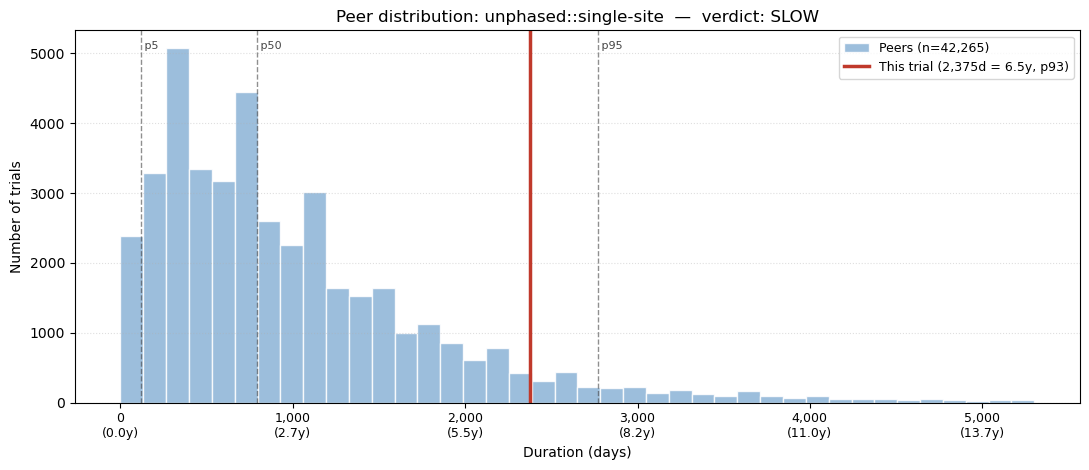


WORKED EXAMPLE — caller-supplied trial
TRIAL AUDIT REPORT
  Peer group:             confirmatory::multinational
  Peer group size:        7,586 trials
  Generated at:           2026-10-06T20:58:25.709586+00:00

  ── DURATION ─────────────────────────────────────────────────
  Actual duration:           1,340.0 days (3.67 years)
  Peer median:                 823.0 days
  Peer p05 / p95:              242.0 / 3,287.8 days
  Peer p10 / p90:              305.0 / 2,466.0 days

  Percentile in peers:      71.6%   |█████████████████████████████░░░░░░░░░░░|
  Delta vs peer median:       +517.0 days (+62.8%)

  ── VERDICT ──────────────────────────────────────────────────
  → TYPICAL

  ── ACTIONABLE FEATURES (design levers) ─────────────────────
  [design ] enrollment_count                       +0.1224  =500
              ↳ Larger enrollment targets are associated with longer durations in this peer group.
  [design ] num_sites                              +0.1124  =40
              ↳ More si

In [46]:
# =============================================================================
# CELL 11: WORKED EXAMPLE — audit a finished trial
# =============================================================================
# Everything marked with  # ← MODIFY  is a knob the user can turn.
# Everything else is pipeline plumbing.
#
# QUICK REFERENCE — acceptable values for the modifiable variables:
#
#   _sample_seed          : any integer              (e.g. 99, 42, 7)
#   _my_trial['study_type'] : 'INTERVENTIONAL' | 'OBSERVATIONAL'
#   _my_trial['phase_score']: 0 | 1 | 2 | 3 | 4      (0=none, 1=Ph1, 2=Ph2, 3=Ph3, 4=Ph4)
#   _my_trial['num_sites']  : any non-negative int   (e.g. 1, 40, 250)
#   _my_trial['num_countries'] : any non-negative int (e.g. 1, 6, 30)
#   _batch_peer_group     : any key from peer_dist.index (see Cell 9 output)
#   _batch_limit          : any positive int         (e.g. 50, 200, 1000)
# =============================================================================


# -----------------------------------------------------------------------------
# --- Option A: audit a trial from the reference corpus -----------------------
# Picks a random trial already in the corpus and audits it end-to-end.
# -----------------------------------------------------------------------------
print("\n" + "=" * 78)
print("WORKED EXAMPLE — trial from the reference corpus")
print("=" * 78)

_sample_seed = 99          # ← MODIFY: any integer (e.g. 99, 42, 7)
                           #    Changing the seed picks a different random trial.

_sample_id = str(corpus[TRIAL_ID_COL].sample(1, random_state=_sample_seed).iloc[0])
_report = audit_trial(trial_id=_sample_id)
print(render_audit_report(_report))
plot_trial_vs_peers(_report, save_path=OUTPUT_DIR / f'audit_{_sample_id}.png')


# -----------------------------------------------------------------------------
# --- Option B: audit a caller-supplied trial --------------------------------
# Audit a trial NOT in the corpus — supply its design features and its
# actual duration manually.
# -----------------------------------------------------------------------------
print("\n" + "=" * 78)
print("WORKED EXAMPLE — caller-supplied trial")
print("=" * 78)

_my_trial = {
    'study_type':      'INTERVENTIONAL',   # ← MODIFY: 'INTERVENTIONAL' or 'OBSERVATIONAL'
                                           #    Example: 'OBSERVATIONAL'

    'phase_score':     3,                  # ← MODIFY: 0 | 1 | 2 | 3 | 4
                                           #    0 = no phase
                                           #    1 = Phase 1 / Early Phase 1
                                           #    2 = Phase 2
                                           #    3 = Phase 3
                                           #    4 = Phase 4
                                           #    Example: 2

    'num_sites':       40,                 # ← MODIFY: any non-negative integer
                                           #    Example: 1, 15, 250

    'num_countries':   6,                  # ← MODIFY: any non-negative integer
                                           #    Example: 1, 3, 30

    'enrollment_count': 500,               # ← MODIFY: any non-negative integer
                                           #    Example: 75, 500, 5000

    'is_oncology':     1,                  # ← MODIFY: 0 or 1
                                           #    1 = oncology trial
                                           #    0 = not oncology
                                           #    Example: 0

    'is_industry_funded': 1,               # ← MODIFY: 0 or 1
                                           #    1 = industry-funded
                                           #    0 = not industry-funded
                                           #    Example: 0
}

_my_actual_duration_days = 1340            # ← MODIFY: any positive float
                                           #    The trial's ACTUAL duration in days.
                                           #    Example: 365, 730, 1825

_my_report = audit_trial(
    features=_my_trial,
    actual_duration_days=_my_actual_duration_days,
)
print(render_audit_report(_my_report))


# -----------------------------------------------------------------------------
# --- Option C: batch audit one peer group ------------------------------------
# Audit many trials at once within a single peer group.
# -----------------------------------------------------------------------------
print("\n" + "=" * 78)
print("WORKED EXAMPLE — batch audit of pivotal::multinational")
print("=" * 78)

_batch_peer_group = 'pivotal::multinational'   # ← MODIFY: any peer group key
                                               #    Example keys:
                                               #      'pivotal::multinational'
                                               #      'confirmatory::single-site'
                                               #      'unphased::regional'
                                               #      'obs::cohort::prospective'
                                               #    Full list: see peer_dist.index
                                               #    (printed in Cell 9's coverage table)

_batch_limit       = 200                        # ← MODIFY: any positive int
                                               #    Example: 50, 200, 1000
                                               #    Caps how many trials to audit.

_batch = batch_audit(peer_group=_batch_peer_group, limit=_batch_limit)
print(_batch.head(20).to_string(index=False))
print(f"\n  Verdict distribution:")
print(_batch['verdict'].value_counts().to_string())

_batch_out = OUTPUT_DIR / f'batch_audit_{_batch_peer_group.replace("::", "_")}.csv'
_batch.to_csv(_batch_out, index=False)
print(f"  ✅ Saved {_batch_out}")


# -----------------------------------------------------------------------------
# --- Persist the audit output directory manifest -----------------------------
# -----------------------------------------------------------------------------
_manifest = {
    'schema_version':  1,
    'generated_by':    '03_clinical_trial_benchmarking_audit',
    'generated_at':    datetime.now(timezone.utc).isoformat(),
    'handoff_source':  str(HANDOFF_PATH),
    'outputs': {
        'peer_group_coverage':  str(OUTPUT_DIR / 'peer_group_coverage.csv'),
        'batch_audit_example':  str(_batch_out),
        'example_plot':         str(OUTPUT_DIR / f'audit_{_sample_id}.png'),
    },
    'witness_report': _report,
    'notes': (
        'Audit outputs are retrospective. No model is trained, no prediction '
        'is made, no deployment decision is issued. Given a finished trial\'s '
        'design features and its actual duration, the audit reports where '
        'that duration sits within its peer-group distribution and which '
        'design features are associated with that position.'
    ),
}
with open(OUTPUT_DIR / 'audit_manifest.json', 'w') as f:
    json.dump(_manifest, f, indent=2, default=str)
print(f"\n  ✅ Saved {OUTPUT_DIR / 'audit_manifest.json'}")
print("=" * 78)


WORKED EXAMPLE — what-if analysis (counterfactual peer audits)
  Source trial:  NCT00424320
  Actual duration: 92 days (0.25 years)
  Baseline peer group (as-designed): confirmatory::regional

WHAT-IF TABLE  (actual duration held fixed)
  Actual duration: 92 days (0.25 years)

     scenario                  peer_group peer_n peer_median_days percentile        verdict delta_vs_median_pct
  as-designed      confirmatory::regional  5,354             851d       2.2% unusually fast              -89.2%
earlier phase           pivotal::regional  5,443             974d       1.6% unusually fast              -90.6%
  later phase      confirmatory::regional  5,354             851d       2.2% unusually fast              -89.2%
  single-site   confirmatory::single-site 17,458             820d       2.3% unusually fast              -88.8%
     regional      confirmatory::regional  5,354             851d       2.2% unusually fast              -89.2%
multinational confirmatory::multinational  7,586 

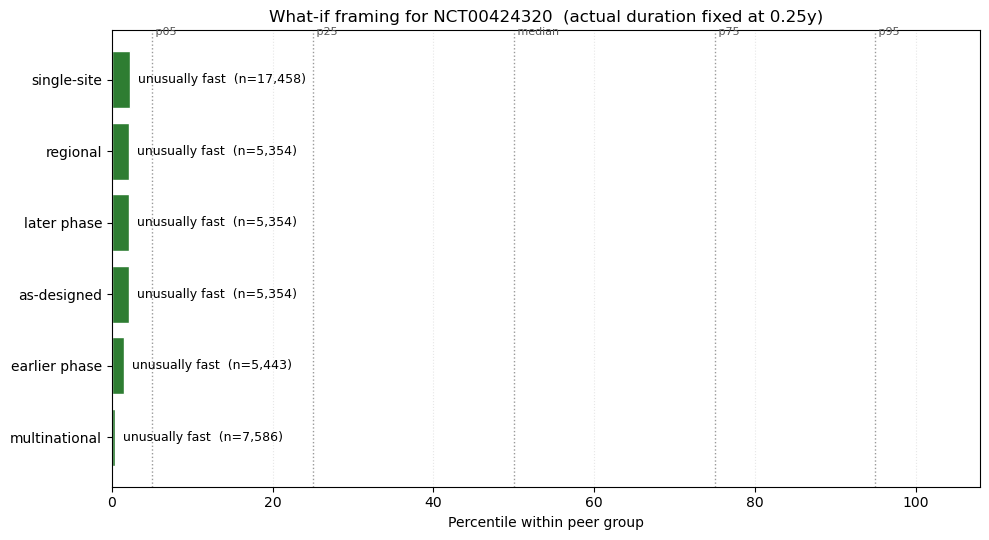

  ✅ Saved audit_output\whatif_NCT00424320.csv

HOW TO READ THIS
  The actual duration is IDENTICAL in every row. Only the reference
  peer group changes. A scenario that reads 'slow' does not mean the
  trial WAS slow — it means that, measured against that peer group,
  this duration sits high in the distribution.

  Use this to:
    - Check whether a trial's 'slow' verdict is an artifact of an
      unusually tight peer group (compare against adjacent scopes).
    - Frame design trade-offs during protocol review: 'if we go
      multinational, what peer median are we signing up against?'

  Do NOT use this to:
    - Claim that changing a design feature WOULD have changed the
      duration. That is a causal question this analysis cannot answer.
    - Report a predicted duration. This cell reports percentiles of a
      FIXED, KNOWN duration against different reference distributions.



In [47]:
# =============================================================================
# CELL 12 WORKED EXAMPLE — what-if analysis (counterfactual peer audits)
# =============================================================================
# Purpose
# -------
# Given a finished trial with a KNOWN actual duration, show what its audit
# verdict would have been if it had been designed differently:
#
#     - a different phase  (e.g. Phase 2 instead of Phase 3)
#     - a different scope  (e.g. multinational instead of single-site)
#     - a different study type (interventional vs observational)
#
# WHY THIS IS NOT A PREDICTION
# ----------------------------
# The actual duration does NOT change in this analysis. Only the PEER GROUP
# the trial is benchmarked against changes. So the output answers:
#
#     "Relative to a DIFFERENT set of peers, how would this trial's actual
#      duration have been judged?"
#
# It is a framing tool for design review, not a forecast. It does NOT claim
# that changing the phase would have changed the duration — it shows how the
# SAME duration reads against a different reference distribution.
#
# HOW TO MODIFY
# -------------
#   _wit_trial_id      : any NCT ID present in the reference corpus
#   _wit_scenarios     : list of (label, overrides_dict)
#                        overrides may include study_type, phase_score,
#                        num_sites, num_countries — anything the partition
#                        reads. Any field you do not override is inherited
#                        from the source trial.
# =============================================================================

print("\n" + "=" * 78)
print("WORKED EXAMPLE — what-if analysis (counterfactual peer audits)")
print("=" * 78)

# -----------------------------------------------------------------------------
# --- 1. Pick the trial to interrogate ----------------------------------------
# -----------------------------------------------------------------------------
# Any NCT present in the reference corpus works. Change _wit_trial_id to audit
# a different finished trial. The trial's ACTUAL duration is held fixed across
# every scenario below.
_wit_trial_id = str(
    corpus[TRIAL_ID_COL].sample(1, random_state=2024).iloc[0]
)   # ← MODIFY: pin an NCT ID, or leave the sample() call to pick one at random

_wit_source = corpus.loc[
    corpus[TRIAL_ID_COL].astype(str) == _wit_trial_id
].iloc[0]

print(f"  Source trial:  {_wit_trial_id}")
print(f"  Actual duration: {float(_wit_source['duration_days']):,.0f} days "
      f"({float(_wit_source['duration_days']) / 365.25:.2f} years)")
print(f"  Baseline peer group (as-designed): "
      f"{audit_trial(trial_id=_wit_trial_id)['peer_group']}")

# -----------------------------------------------------------------------------
# --- 2. Define the scenarios -------------------------------------------------
# -----------------------------------------------------------------------------
# Each scenario is a (label, overrides) pair. Fields not listed in `overrides`
# are inherited from the source trial. The actual duration is NEVER overridden.
_wit_scenarios = [
    ("as-designed", {}),                       # ← MODIFY: rename / reorder freely
    ("earlier phase",        {'phase_score': 2}),
    ("later phase",          {'phase_score': 3}),
    ("single-site",          {'num_sites': 1,  'num_countries': 1}),
    ("regional",             {'num_sites': 8,  'num_countries': 3}),
    ("multinational",        {'num_sites': 40, 'num_countries': 12}),
]

# -----------------------------------------------------------------------------
# --- 3. Run the counterfactual audit for each scenario -----------------------
# -----------------------------------------------------------------------------
_wit_rows = []
for _label, _overrides in _wit_scenarios:
    # Build the feature dict for this scenario. Inherit from the source row,
    # then apply the overrides. The actual duration is passed unchanged.
    _features = _wit_source.to_dict()
    for _k, _v in _overrides.items():
        _features[_k] = _v

    # Determine the peer group this scenario would resolve to. We do NOT use
    # audit_trial's peer_group_override here because we want the audit to go
    # through the SAME deterministic partition path used in production.
    _row_df = pd.DataFrame([{
        'study_type':    _features.get('study_type', 'INTERVENTIONAL'),
        'phase_score':   _features.get('phase_score', 0),
        'num_sites':     _features.get('num_sites', 0),
        'num_countries': _features.get('num_countries', 0),
    }])
    _pg = str(build_strategy_A_partition(_row_df).iloc[0])

    _report = audit_trial(
        features=_features,
        actual_duration_days=float(_wit_source['duration_days']),
        peer_group_override=_pg,
    )

    # audit_trial may return an 'unknown_peer_group' status if the scenario
    # lands on a peer group absent from the distribution table. Record that
    # without crashing — it is itself a useful finding.
    if 'verdict' not in _report:
        _wit_rows.append({
            'scenario':         _label,
            'peer_group':       _report.get('peer_group', _pg),
            'peer_n':           None,
            'peer_median_days': None,
            'percentile':       None,
            'verdict':          'no_distribution',
            'delta_vs_median_pct': None,
        })
        continue

    _wit_rows.append({
        'scenario':         _label,
        'peer_group':       _report['peer_group'],
        'peer_n':           _report['peer_group_size'],
        'peer_median_days': _report['peer_median_days'],
        'percentile':       _report['percentile'],
        'verdict':          _report['verdict'],
        'delta_vs_median_pct': _report['delta_vs_median_pct'],
    })

_wit_df = pd.DataFrame(_wit_rows)

# -----------------------------------------------------------------------------
# --- 4. Render the comparison table ------------------------------------------
# -----------------------------------------------------------------------------
print()
print("=" * 78)
print("WHAT-IF TABLE  (actual duration held fixed)")
print("=" * 78)
print(f"  Actual duration: {float(_wit_source['duration_days']):,.0f} days "
      f"({float(_wit_source['duration_days']) / 365.25:.2f} years)")
print()

# Format for readability. Percentile and delta are the load-bearing columns.
_wit_display = _wit_df.copy()
_wit_display['percentile'] = _wit_display['percentile'].apply(
    lambda v: f"{v:5.1f}%" if pd.notna(v) else "  n/a"
)
_wit_display['delta_vs_median_pct'] = _wit_display['delta_vs_median_pct'].apply(
    lambda v: f"{v:+6.1f}%" if pd.notna(v) else "   n/a"
)
_wit_display['peer_median_days'] = _wit_display['peer_median_days'].apply(
    lambda v: f"{v:,.0f}d" if pd.notna(v) else "n/a"
)
_wit_display['peer_n'] = _wit_display['peer_n'].apply(
    lambda v: f"{int(v):,}" if pd.notna(v) else "n/a"
)

print(_wit_display.to_string(index=False))
print()

# -----------------------------------------------------------------------------
# --- 5. Rank scenarios by verdict severity -----------------------------------
# -----------------------------------------------------------------------------
# Severity ordering lets us highlight the "best-case" and "worst-case" peer
# framings for the same actual duration. This is the headline insight of the
# what-if analysis: the SAME trial reads differently depending on who you
# compare it to.
_SEVERITY = {
    'unusually fast': 0,
    'fast':           1,
    'typical':        2,
    'slow':           3,
    'unusually slow': 4,
    'no_distribution': 5,
    'unknown':         5,
}

_wit_ranked = _wit_df.copy()
_wit_ranked['_severity'] = _wit_ranked['verdict'].map(_SEVERITY).fillna(5)
_wit_ranked = _wit_ranked.sort_values('_severity')

print("=" * 78)
print("RANKED BY VERDICT (fastest-reading framing first)")
print("=" * 78)
for _, _r in _wit_ranked.iterrows():
    _pct = f"{_r['percentile']:5.1f}%" if pd.notna(_r['percentile']) else "  n/a"
    print(f"  {_r['verdict']:<16} | p{_pct} | "
          f"{_r['scenario']:<16} -> {_r['peer_group']}")

print()

# -----------------------------------------------------------------------------
# --- 6. Bar chart: percentile by scenario ------------------------------------
# -----------------------------------------------------------------------------
# A horizontal bar chart reads more naturally than a vertical one here because
# the scenario labels are long. The 50th percentile is marked as a reference
# line so the "typical" band is visually obvious.
_plot_df = _wit_df.dropna(subset=['percentile']).copy()
if len(_plot_df) > 0:
    _plot_df = _plot_df.sort_values('percentile')

    _colors = {
        'unusually fast': '#2e7d32',
        'fast':           '#66bb6a',
        'typical':        '#90a4ae',
        'slow':           '#ef6c00',
        'unusually slow': '#c0392b',
    }

    fig, ax = plt.subplots(figsize=(10, 0.55 * len(_plot_df) + 2.2))
    _bars = ax.barh(
        _plot_df['scenario'],
        _plot_df['percentile'],
        color=[_colors.get(v, '#90a4ae') for v in _plot_df['verdict']],
        edgecolor='white',
    )

    # Reference lines for the verdict bands.
    for _x, _lbl in [(5, 'p05'), (25, 'p25'), (50, 'median'),
                     (75, 'p75'), (95, 'p95')]:
        ax.axvline(_x, color='#555', linestyle=':', linewidth=1, alpha=0.6)
        ax.text(_x, len(_plot_df) - 0.4, f" {_lbl}",
                fontsize=8, color='#555', ha='left', va='bottom')

    # Annotate each bar with its verdict and peer-group size.
    for _bar, (_, _row) in zip(_bars, _plot_df.iterrows()):
        _w = _bar.get_width()
        ax.text(
            _w + 1.0, _bar.get_y() + _bar.get_height() / 2,
            f"{_row['verdict']}  (n={int(_row['peer_n']):,})",
            va='center', fontsize=9,
        )

    ax.set_xlim(0, 108)
    ax.set_xlabel("Percentile within peer group")
    ax.set_title(
        f"What-if framing for {_wit_trial_id}  "
        f"(actual duration fixed at "
        f"{float(_wit_source['duration_days']) / 365.25:.2f}y)"
    )
    ax.grid(axis='x', linestyle=':', alpha=0.3)
    plt.tight_layout()

    _wit_plot_path = OUTPUT_DIR / f'whatif_{_wit_trial_id}.png'
    plt.savefig(_wit_plot_path, dpi=150, bbox_inches='tight')
    print(f"  ✅ Saved {_wit_plot_path}")
    plt.show()
    plt.close()
else:
    print("  ⚠️ No scenario produced a resolvable peer distribution — "
          "skipping chart.")

# -----------------------------------------------------------------------------
# --- 7. Persist the comparison ------------------------------------------------
# -----------------------------------------------------------------------------
_wit_out = OUTPUT_DIR / f'whatif_{_wit_trial_id}.csv'
_wit_df.to_csv(_wit_out, index=False)
print(f"  ✅ Saved {_wit_out}")

# -----------------------------------------------------------------------------
# --- 8. Interpretation caveat -------------------------------------------------
# -----------------------------------------------------------------------------
print()
print("=" * 78)
print("HOW TO READ THIS")
print("=" * 78)
print(
    "  The actual duration is IDENTICAL in every row. Only the reference\n"
    "  peer group changes. A scenario that reads 'slow' does not mean the\n"
    "  trial WAS slow — it means that, measured against that peer group,\n"
    "  this duration sits high in the distribution.\n"
    "\n"
    "  Use this to:\n"
    "    - Check whether a trial's 'slow' verdict is an artifact of an\n"
    "      unusually tight peer group (compare against adjacent scopes).\n"
    "    - Frame design trade-offs during protocol review: 'if we go\n"
    "      multinational, what peer median are we signing up against?'\n"
    "\n"
    "  Do NOT use this to:\n"
    "    - Claim that changing a design feature WOULD have changed the\n"
    "      duration. That is a causal question this analysis cannot answer.\n"
    "    - Report a predicted duration. This cell reports percentiles of a\n"
    "      FIXED, KNOWN duration against different reference distributions.\n"
)
print("=" * 78)